# Airfoil Self-Noise Dataset

In [1]:
%pip install pandas
%pip install statsmodels
%pip install matplotlib
%pip install seaborn

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import io
import ssl
from urllib.request import urlopen

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00291/airfoil_self_noise.dat"
columns = ['Frequency', 
        'Angle_of_Attack', 
        'Chord_Length', 
        'Free_Stream_Velocity', 
        'Displacement_Thickness', 
        'Sound_Pressure_Level']

ssl_context = ssl._create_unverified_context()
with urlopen(url, context=ssl_context) as response:
    data = response.read()

df = pd.read_csv(io.BytesIO(data), sep='\t', header=None, names=columns)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1503, 6)


,Frequency,Angle_of_Attack,Chord_Length,Free_Stream_Velocity,Displacement_Thickness,Sound_Pressure_Level
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


## Step 1: Preprocessing
- **Missing Values:** Check for any null entries.
- **String/Categorical Values:** Verify data types.
- **Outliers:** Check feature bounds using the IQR technique.

Frequency                 0
Angle_of_Attack           0
Chord_Length              0
Free_Stream_Velocity      0
Displacement_Thickness    0
Sound_Pressure_Level      0
dtype: int64

No missing values detected in the dataset.

Frequency                   int64
Angle_of_Attack           float64
Chord_Length              float64
Free_Stream_Velocity      float64
Displacement_Thickness    float64
Sound_Pressure_Level      float64
dtype: object

No string values detected in the dataset.


Checking for outliers



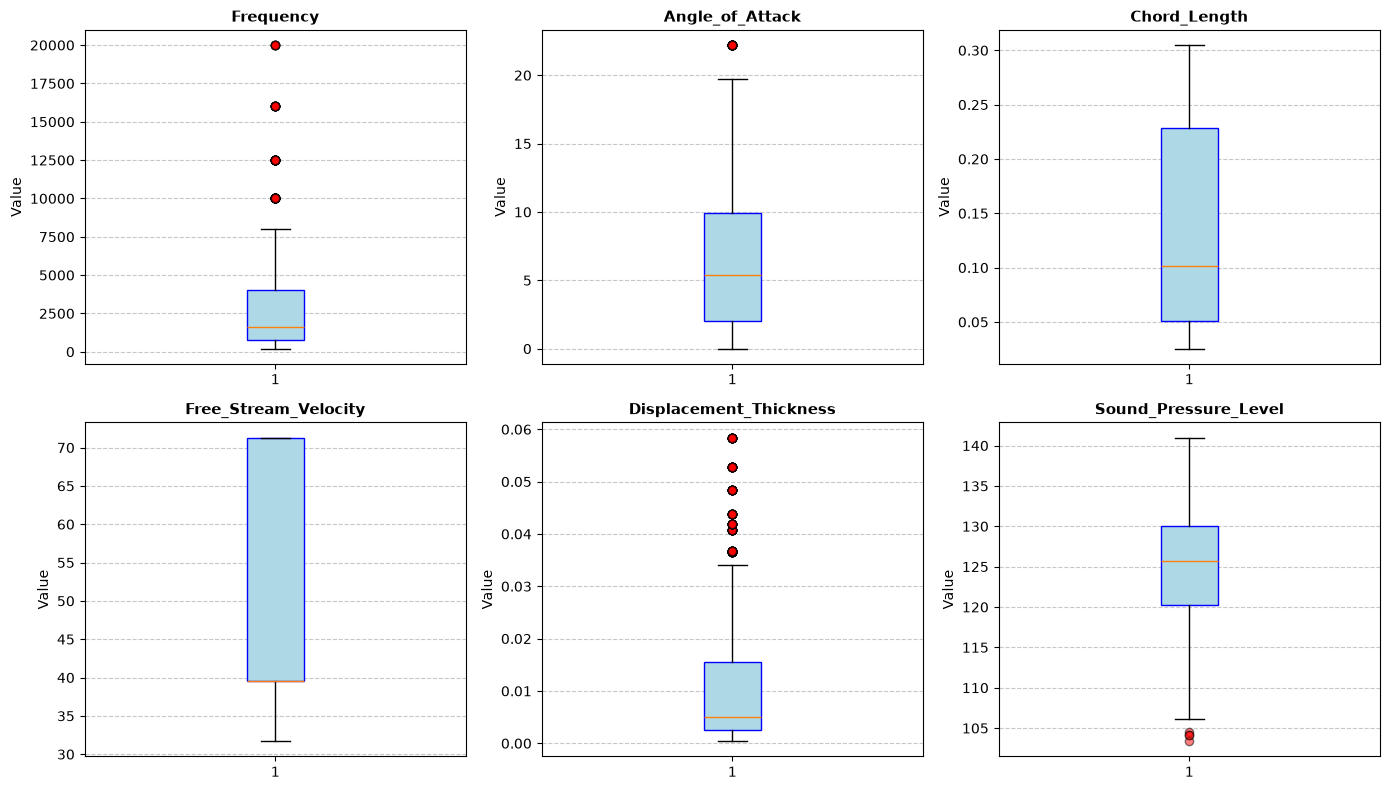


Frequency
Lower bound: -4000.00
Upper bound: 8800.00
Potential outliers: 86

Angle_of_Attack
Lower bound: -9.85
Upper bound: 21.75
Potential outliers: 30

Chord_Length
Lower bound: -0.22
Upper bound: 0.50
Potential outliers: 0

Free_Stream_Velocity
Lower bound: -7.95
Upper bound: 118.85
Potential outliers: 0

Displacement_Thickness
Lower bound: -0.02
Upper bound: 0.04
Potential outliers: 124

Sound_Pressure_Level
Lower bound: 105.48
Upper bound: 144.70
Potential outliers: 4


In [3]:
print(df.isnull().sum())
print("\nNo missing values detected in the dataset.\n")

print(df.dtypes)
print("\nNo string values detected in the dataset.\n")

print("\nChecking for outliers\n")
# Check for outliers
df.describe()

# Create boxplots for each column
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes_flat = axes.flatten()

for ax, column in zip(axes_flat, df.columns):
    ax.boxplot(df[column], patch_artist=True, 
               boxprops=dict(facecolor='lightblue', color='blue'),
               flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.5))
    ax.set_title(column, fontsize=11, fontweight='bold')
    ax.set_ylabel("Value")
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]
    
    return Q1, Q3, IQR, lower_bound, upper_bound, outliers

for column in df.columns:
    Q1, Q3, IQR, lower, upper, outliers = find_outliers_iqr(df, column)
    
    print(f"\n{column}")
    print(f"Lower bound: {lower:.2f}")
    print(f"Upper bound: {upper:.2f}")
    print(f"Potential outliers: {len(outliers)}")

The outliers in this code represent the actual real worlds physics when aircrafts are put under these conditions. As such, they should not be taken out of the dataset, as it will lead to the loss of our understanding in the effects casued by these extreme conditions.

## Step 2: Statistical Summaries

In [4]:
df.to_csv("../data/airfoil_self_noise.csv", index=False)
print("Statistics Summary")
display(df.describe().T.round(3))

Statistics Summary


,count,mean,std,min,25%,50%,75%,max
Frequency,1503.0,2886.381,3152.573,200.000,800.000,1600.000,4000.000,20000.000
Angle_of_Attack,1503.0,6.782,5.918,0.000,2.000,5.400,9.900,22.200
Chord_Length,1503.0,0.137,0.094,0.025,0.051,0.102,0.229,0.305
Free_Stream_Velocity,1503.0,50.861,15.573,31.700,39.600,39.600,71.300,71.300
Displacement_Thickness,1503.0,0.011,0.013,0.000,0.003,0.005,0.016,0.058
Sound_Pressure_Level,1503.0,124.836,6.899,103.380,120.191,125.721,129.996,140.987


## Step 3: Correlation Analysis


Correlation Matrix


,Frequency,Angle_of_Attack,Chord_Length,Free_Stream_Velocity,Displacement_Thickness,Sound_Pressure_Level
Frequency,1.000000,-0.272765,-0.003661,0.133664,-0.230107,-0.390711
Angle_of_Attack,-0.272765,1.000000,-0.504868,0.058760,0.753394,-0.156108
Chord_Length,-0.003661,-0.504868,1.000000,0.003787,-0.220842,-0.236162
Free_Stream_Velocity,0.133664,0.058760,0.003787,1.000000,-0.003974,0.125103
Displacement_Thickness,-0.230107,0.753394,-0.220842,-0.003974,1.000000,-0.312670
Sound_Pressure_Level,-0.390711,-0.156108,-0.236162,0.125103,-0.312670,1.000000



Heatmap of Correlation Matrix


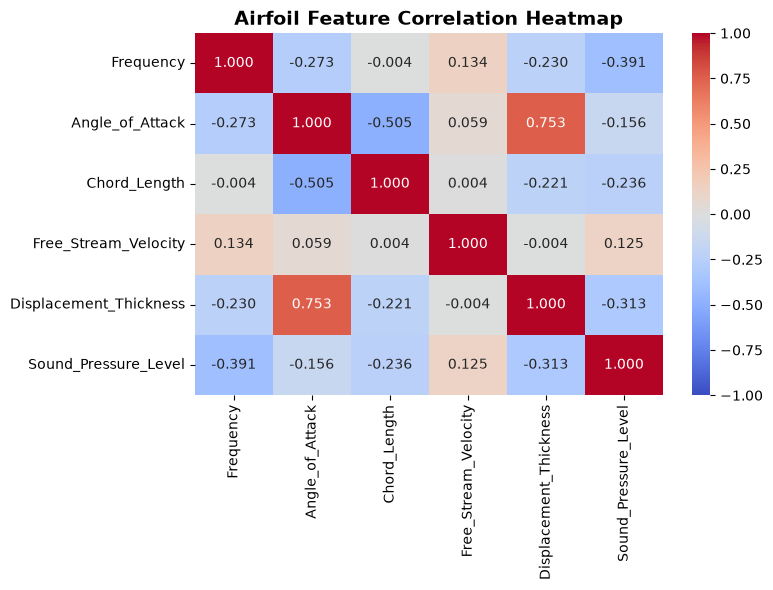

In [5]:
correlation_matrix = df.corr()
print("\nCorrelation Matrix")
display(correlation_matrix)

print("\nHeatmap of Correlation Matrix")
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1)
plt.title("Airfoil Feature Correlation Heatmap", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## Step 4: Simple Regression 
1. **Frequency** ($r = -0.391$)
2. **Displacement_Thickness** ($r = -0.313$)

                             OLS Regression Results                             
Dep. Variable:     Sound_Pressure_Level   R-squared:                       0.153
Model:                              OLS   Adj. R-squared:                  0.152
Method:                   Least Squares   F-statistic:                     270.4
Date:                  Tue, 08 Sep 2026   Prob (F-statistic):           5.36e-56
Time:                          08:02:04   Log-Likelihood:                -4910.5
No. Observations:                  1503   AIC:                             9825.
Df Residuals:                      1501   BIC:                             9836.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        127.3037      0.222

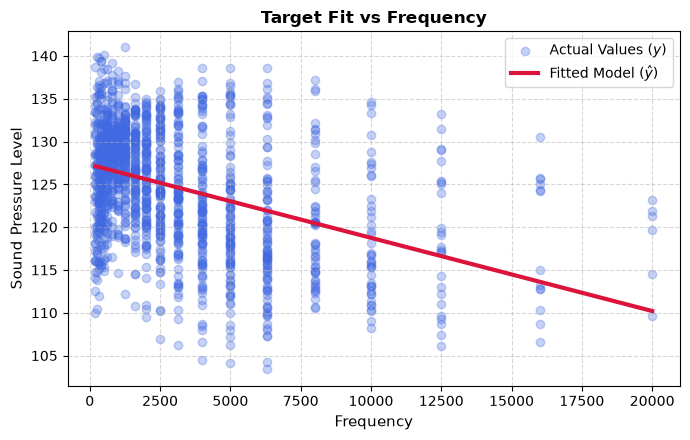

                             OLS Regression Results                             
Dep. Variable:     Sound_Pressure_Level   R-squared:                       0.098
Model:                              OLS   Adj. R-squared:                  0.097
Method:                   Least Squares   F-statistic:                     162.6
Date:                  Tue, 08 Sep 2026   Prob (F-statistic):           1.92e-35
Time:                          08:02:04   Log-Likelihood:                -4957.6
No. Observations:                  1503   AIC:                             9919.
Df Residuals:                      1501   BIC:                             9930.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const   

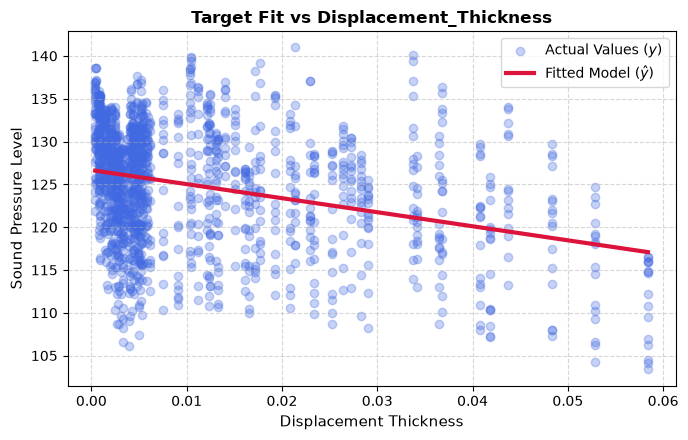

In [6]:
X = sm.add_constant(df['Frequency'])
y = df['Sound_Pressure_Level']

model = sm.OLS(y, X).fit()
print(model.summary())

    
df['y_hat'] = model.predict(X)
    
plt.figure(figsize=(7, 4.5))
plt.scatter(df['Frequency'], df['Sound_Pressure_Level'], color='royalblue', alpha=0.3, label='Actual Values ($y$)')
    
sorted_df = df.sort_values(by='Frequency')
plt.plot(sorted_df['Frequency'], sorted_df['y_hat'], color='crimson', linewidth=3, label='Fitted Model ($\\hat{y}$)')

plt.xlabel('Frequency', fontsize=11)
plt.ylabel('Sound Pressure Level', fontsize=11)
plt.title(f"Target Fit vs Frequency", fontsize=12, weight='bold')
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

X = sm.add_constant(df['Displacement_Thickness'])
y = df['Sound_Pressure_Level']

model = sm.OLS(y, X).fit()
print(model.summary())

    
df['y_hat'] = model.predict(X)
    
plt.figure(figsize=(7, 4.5))
plt.scatter(df['Displacement_Thickness'], df['Sound_Pressure_Level'], color='royalblue', alpha=0.3, label='Actual Values ($y$)')
    
sorted_df = df.sort_values(by='Displacement_Thickness')
plt.plot(sorted_df['Displacement_Thickness'], sorted_df['y_hat'], color='crimson', linewidth=3, label='Fitted Model ($\\hat{y}$)')

plt.xlabel('Displacement Thickness', fontsize=11)
plt.ylabel('Sound Pressure Level', fontsize=11)
plt.title(f"Target Fit vs Displacement_Thickness", fontsize=12, weight='bold')
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Summary Statement
1. Frequency: The Frequency and the target variable have a negative correlation, where for every 1 Hz increase in Frequency the Sound Pressure decreases by approximately .0009 dB. We also have 95% confidence that the true baseline falls somehwere between 126.868-127.740 dB and the true slope falls somewhere between -0.001 and -0.001 dB per Hz

2. Displacement_Thickness: The Displacement Thinckness and the target variable have a negative correlation, where for every 1 mm increase in Displacement Thickness the Sound Pressure decreases by approximately 0.164 dB. We also have 95% confidence that the true baseline falls somehwere between 0.125-0.127 dB and the true slope falls somewhere between -0.189 and -0.138 dB per mm